# Experiment: Roadrunner EGP Phase-60 NC + Non-Frac Fsed Sweep

Goal:

- Fix the planet/star condition at `T=1000 K`, `a=5 AU`, `Rp=1.0 Rj`, `phase=60 deg`, and `g31`.
- Plan `NC` as the zero cloud-fraction case plus exact non-`frac` EGP cloud sedimentation cases: `fsed0.3`, `fsed1`, `fsed3`, `fsed6`, and `fsed8`.
- Use Route C: matching SLGRID PT + cloud files for reflected light and matching EGP IRflux files for thermal flux.
- Run every planned case whose exact non-`frac` inputs are present, and report the missing cases for follow-up.
- Produce a table and figure: reflected fraction vs cloud case for CGI-1, CGI-2, CGI-3, and CGI-4.

Note: the local `T500/g31/m+000/CO100` grid currently has only one complete exact non-`frac` Route C case (`fsed3`). The `T1000` grid has four complete cases now (`NC`, `fsed1`, `fsed3`, `fsed6`), so this notebook uses `T1000` to run an actual multi-point fsed sweep.


In [1]:
# Setup: PICASO4-local imports and paths
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]
SEARCH_ROOTS.append(Path("/Users/xin/Documents/Documents/College/aurora"))

for candidate in SEARCH_ROOTS:
    if (candidate / "roadrunner_egp" / "roadrunner").exists():
        REPO_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate aurora/roadrunner_egp/roadrunner.")

ROADRUNNER_ROOT = REPO_ROOT / "roadrunner_egp"
SCIENCE_INPUTS = REPO_ROOT / "science_inputs"
RESULTS_DIR = ROADRUNNER_ROOT / "results" / "phase60_t1000_a5_g31_fsed_sweep"
TMP_DIR = REPO_ROOT / "tmp"

for path in (RESULTS_DIR, TMP_DIR / "matplotlib", TMP_DIR / "numba-cache"):
    path.mkdir(parents=True, exist_ok=True)

# Force this notebook to use the Aurora data.
os.environ["ROADRUNNER_SCIENCE_INPUTS"] = str(SCIENCE_INPUTS)
os.environ["picaso_refdata"] = str(REPO_ROOT / "picaso4_reference")
os.environ["PYSYN_CDBS"] = str(REPO_ROOT / "picaso4_reference" / "stellar_grids")
os.environ["SLGRID_BASE_DIR"] = str(SCIENCE_INPUTS / "slgrid")
os.environ["SLGRID_PT_DIR"] = str(SCIENCE_INPUTS / "slgrid" / "climate")
os.environ["SLGRID_CLD_DIR"] = str(SCIENCE_INPUTS / "slgrid" / "clouds")
os.environ["EGP_IRFLUX_DIR"] = str(SCIENCE_INPUTS / "egp" / "irflux")
os.environ["MPLCONFIGDIR"] = str(TMP_DIR / "matplotlib")
os.environ["NUMBA_CACHE_DIR"] = str(TMP_DIR / "numba-cache")

if str(ROADRUNNER_ROOT) not in sys.path:
    sys.path.insert(0, str(ROADRUNNER_ROOT))

# Make repeated top-to-bottom notebook runs use the env vars above.
for module_name in list(sys.modules):
    if (
        module_name == "roadrunner"
        or module_name.startswith("roadrunner.")
        or module_name == "workflows.phase60_fsed_sweep"
        or module_name == "workflows.hybrid_reflected_picaso_thermal_egp"
    ):
        del sys.modules[module_name]

from workflows.phase60_fsed_sweep import (
    HAVE_PICASO,
    REFLECT_THRESHOLD,
    fsed_sweep_pivot,
    gravity_code_to_logg_cgs,
    phase60_fsed_file_inventory,
    plot_phase60_fsed_sweep,
    run_phase60_fsed_sweep,
)
from roadrunner.config import (
    CGI_BANDS,
    EGP_IRFLUX_DIR,
    LAM_GRID,
    SLGRID_CLD_DIR,
    SLGRID_PT_DIR,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Notebook results: {RESULTS_DIR}")
print(f"PICASO available: {HAVE_PICASO}")
print(f"picaso_refdata: {os.environ['picaso_refdata']}")
print(f"PYSYN_CDBS: {os.environ['PYSYN_CDBS']}")
print(f"SLGRID climate: {SLGRID_PT_DIR}")
print(f"SLGRID clouds: {SLGRID_CLD_DIR}")
print(f"EGP IRflux: {EGP_IRFLUX_DIR}")
print(f"Wavelength grid: {LAM_GRID.min():.2f}-{LAM_GRID.max():.2f} um ({len(LAM_GRID)} pts)")
print(f"CGI bands: {list(CGI_BANDS.keys())}")


Repo root: /Users/dhuang/Documents/daniel/research/aurora
Notebook results: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t1000_a5_g31_fsed_sweep
PICASO available: True
picaso_refdata: /Users/dhuang/Documents/daniel/research/aurora/picaso4_reference
PYSYN_CDBS: /Users/dhuang/Documents/daniel/research/aurora/picaso4_reference/stellar_grids
SLGRID climate: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/slgrid/climate
SLGRID clouds: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/slgrid/clouds
EGP IRflux: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/egp/irflux
Wavelength grid: 0.30-1.00 um (1200 pts)
CGI bands: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']


## Fixed Run Configuration

This is the phase-60 Route C version of the gravity sweep flow. The planned swept variable is `NC` plus exact non-`frac` `fsed`; all other physical settings are fixed. The notebook runs the subset with complete exact inputs so it remains executable while the missing non-`frac` IRflux files for `fsed0.3` and `fsed8` are being assembled.


In [2]:
TEMPERATURE_K = 1000
GRAVITY_CODE = "31"
PLANNED_FSED_VALUES = ["NC", "0.3", "1", "3", "6", "8"]
METALLICITY = "+000"
CO_RATIO = "100"

PHASE_DEG = 60.0
R_PLANET_RJ = 1.0
SEMI_MAJOR_AU = 5.0

OUTPUT_CSV = RESULTS_DIR / "roadrunner_egp_phase60_T1000_a5_g31_fsed_sweep.csv"
OUTPUT_PNG = RESULTS_DIR / "roadrunner_egp_phase60_T1000_a5_g31_fsed_sweep.png"

config_summary = pd.DataFrame(
    [
        {"parameter": "temperature_k", "value": TEMPERATURE_K},
        {"parameter": "gravity_code", "value": GRAVITY_CODE},
        {"parameter": "logg_cgs", "value": round(gravity_code_to_logg_cgs(GRAVITY_CODE), 6)},
        {"parameter": "planned_fsed_values", "value": PLANNED_FSED_VALUES},
        {"parameter": "metallicity", "value": METALLICITY},
        {"parameter": "co_ratio", "value": CO_RATIO},
        {"parameter": "phase_deg", "value": PHASE_DEG},
        {"parameter": "r_planet_rj", "value": R_PLANET_RJ},
        {"parameter": "semi_major_au", "value": SEMI_MAJOR_AU},
        {"parameter": "thermal_source", "value": "egp"},
        {"parameter": "atmosphere_source", "value": "slgrid"},
        {"parameter": "frac_allowed", "value": False},
        {"parameter": "threshold", "value": REFLECT_THRESHOLD},
    ]
)

display(config_summary)


,parameter,value
0,temperature_k,1000
1,gravity_code,31
2,logg_cgs,3.491362
3,planned_fsed_values,"[NC, 0.3, 1, 3, 6, 8]"
4,metallicity,+000
5,co_ratio,100
6,phase_deg,60.0
7,r_planet_rj,1.0
8,semi_major_au,5.0
9,thermal_source,egp


## Preflight: Exact Non-Frac Route C Inventory

`NC` has no cloud file because it is the zero cloud-fraction case. The preflight separates the planned cases into complete runnable cases and missing cases. Missing rows are displayed but do not stop the available exact cases from running.


In [3]:
file_inventory = phase60_fsed_file_inventory(
    temperature_k=TEMPERATURE_K,
    gravity_code=GRAVITY_CODE,
    fsed_values=PLANNED_FSED_VALUES,
    metallicity=METALLICITY,
    co_ratio=CO_RATIO,
)

for column in ("pt_file", "cld_file", "egp_irflux_file"):
    frac_mask = file_inventory[column].str.contains("_frac", regex=False, na=False)
    if frac_mask.any():
        raise ValueError(f"Non-frac sweep selected frac file(s) in {column}.")

complete_mask = (
    file_inventory["pt_exists"]
    & file_inventory["cld_exists"]
    & file_inventory["egp_irflux_exists"]
)
complete_inventory = file_inventory.loc[complete_mask].copy()
missing_inventory = file_inventory.loc[~complete_mask].copy()

RUN_FSED_VALUES = complete_inventory["fsed"].tolist()

print(f"Planned cases: {PLANNED_FSED_VALUES}")
print(f"Runnable exact Route C cases: {RUN_FSED_VALUES}")

if not missing_inventory.empty:
    print("Missing exact non-frac Route C inputs; these cases will be skipped until files are added:")
    display(
        missing_inventory[
            [
                "fsed",
                "pt_exists",
                "pt_path",
                "cld_exists",
                "cld_path",
                "egp_irflux_exists",
                "egp_irflux_path",
                "related_pt_files",
                "related_cld_files",
            ]
        ]
    )

if complete_inventory.empty:
    raise FileNotFoundError("No complete exact non-frac Route C cases are available to run.")

display(file_inventory)
print("Preflight passed for available exact Route C cases.")


Planned cases: ['NC', '0.3', '1', '3', '6', '8']
Runnable exact Route C cases: ['NC', '1', '3', '6']
Missing exact non-frac Route C inputs; these cases will be skipped until files are added:


,fsed,pt_exists,pt_path,cld_exists,cld_path,egp_irflux_exists,egp_irflux_path,related_pt_files,related_cld_files
1,0.3,True,/Users/dhuang/Documents/daniel/research/aurora...,True,/Users/dhuang/Documents/daniel/research/aurora...,False,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T1000_g31_m+000_CO100_fsed0.3_frac10_fu...,SLGRID_T1000_g31_m+000_CO100_fsed0.3_frac10_pi...
5,8,True,/Users/dhuang/Documents/daniel/research/aurora...,True,/Users/dhuang/Documents/daniel/research/aurora...,False,/Users/dhuang/Documents/daniel/research/aurora...,SLGRID_T1000_g31_m+000_CO100_fsed8_frac10_full...,SLGRID_T1000_g31_m+000_CO100_fsed8_frac10_pica...


,fsed,fsed_numeric,gravity_code,logg,pt_file,pt_path,pt_exists,cld_file,cld_path,cld_exists,egp_irflux_file,egp_irflux_path,egp_irflux_exists,related_pt_files,related_cld_files
0,NC,0.0,31,3.491362,SLGRID_T1000_g31_m+000_CO100_NC_full.pt,/Users/dhuang/Documents/daniel/research/aurora...,True,none,,True,SLGRID_T1000_g31_m+000_CO100_NC_IRflux.txt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_NC_full.pt,
1,0.3,0.3,31,3.491362,SLGRID_T1000_g31_m+000_CO100_fsed0.3_full.pt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed0.3_picaso.cld,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed0.3_IRflux.txt,/Users/dhuang/Documents/daniel/research/aurora...,False,SLGRID_T1000_g31_m+000_CO100_fsed0.3_frac10_fu...,SLGRID_T1000_g31_m+000_CO100_fsed0.3_frac10_pi...
2,1,1.0,31,3.491362,SLGRID_T1000_g31_m+000_CO100_fsed1_full.pt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed1_picaso.cld,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed1_IRflux.txt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed1_frac10_full...,SLGRID_T1000_g31_m+000_CO100_fsed1_frac10_pica...
3,3,3.0,31,3.491362,SLGRID_T1000_g31_m+000_CO100_fsed3_full.pt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed3_picaso.cld,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed3_IRflux.txt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed3_frac10_full...,SLGRID_T1000_g31_m+000_CO100_fsed3_frac10_pica...
4,6,6.0,31,3.491362,SLGRID_T1000_g31_m+000_CO100_fsed6_full.pt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed6_picaso.cld,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed6_IRflux.txt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed6_frac10_full...,SLGRID_T1000_g31_m+000_CO100_fsed6_frac10_pica...
5,8,8.0,31,3.491362,SLGRID_T1000_g31_m+000_CO100_fsed8_full.pt,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed8_picaso.cld,/Users/dhuang/Documents/daniel/research/aurora...,True,SLGRID_T1000_g31_m+000_CO100_fsed8_IRflux.txt,/Users/dhuang/Documents/daniel/research/aurora...,False,SLGRID_T1000_g31_m+000_CO100_fsed8_frac10_full...,SLGRID_T1000_g31_m+000_CO100_fsed8_frac10_pica...


Preflight passed for available exact Route C cases.


## Main Run

This cell runs one fixed phase-60 Route C case per fsed value and saves a combined CSV.


In [4]:
if not HAVE_PICASO:
    raise RuntimeError("PICASO is not available in this notebook kernel.")

sweep_df = run_phase60_fsed_sweep(
    teff_k=TEMPERATURE_K,
    rj=R_PLANET_RJ,
    a_au=SEMI_MAJOR_AU,
    gravity_code=GRAVITY_CODE,
    fsed_values=RUN_FSED_VALUES,
    phase_deg=PHASE_DEG,
    metallicity=METALLICITY,
    co_ratio=CO_RATIO,
)

sweep_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved detailed fsed-sweep results to: {OUTPUT_CSV}")
print(f"Rows: {len(sweep_df)}")

if not missing_inventory.empty:
    missing_csv = RESULTS_DIR / "roadrunner_egp_phase60_T1000_a5_g31_fsed_missing_inputs.csv"
    missing_inventory.to_csv(missing_csv, index=False)
    print(f"Saved missing-input report to: {missing_csv}")

display(sweep_df)


Saved detailed fsed-sweep results to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t1000_a5_g31_fsed_sweep/roadrunner_egp_phase60_T1000_a5_g31_fsed_sweep.csv
Rows: 16
Saved missing-input report to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t1000_a5_g31_fsed_sweep/roadrunner_egp_phase60_T1000_a5_g31_fsed_missing_inputs.csv


,T_eff,logg,R_p_Rj,a_AU,phase_deg,band,f_reflect,Fp_ref_band,Fp_th_band,decision,gravity_code,fsed,fsed_numeric,pt_file,cld_file,egp_irflux_file
0,1000.0,3.491362,1.0,5.0,60.0,CGI-1,3.467088e-02,0.071607,1.993728,False,31,NC,0.0,SLGRID_T1000_g31_m+000_CO100_NC_full.pt,none,SLGRID_T1000_g31_m+000_CO100_NC_IRflux.txt
1,1000.0,3.491362,1.0,5.0,60.0,CGI-2,3.183513e-05,0.118334,3716.959921,False,31,NC,0.0,SLGRID_T1000_g31_m+000_CO100_NC_full.pt,none,SLGRID_T1000_g31_m+000_CO100_NC_IRflux.txt
2,1000.0,3.491362,1.0,5.0,60.0,CGI-3,1.055139e-05,0.087551,8297.459114,False,31,NC,0.0,SLGRID_T1000_g31_m+000_CO100_NC_full.pt,none,SLGRID_T1000_g31_m+000_CO100_NC_IRflux.txt
3,1000.0,3.491362,1.0,5.0,60.0,CGI-4,3.637928e-07,0.051880,142607.266881,False,31,NC,0.0,SLGRID_T1000_g31_m+000_CO100_NC_full.pt,none,SLGRID_T1000_g31_m+000_CO100_NC_IRflux.txt
4,1000.0,3.491362,1.0,5.0,60.0,CGI-1,2.125151e-02,0.513389,23.644355,False,31,1,1.0,SLGRID_T1000_g31_m+000_CO100_fsed1_full.pt,SLGRID_T1000_g31_m+000_CO100_fsed1_picaso.cld,SLGRID_T1000_g31_m+000_CO100_fsed1_IRflux.txt
5,1000.0,3.491362,1.0,5.0,60.0,CGI-2,2.623668e-04,3.010726,11472.246811,False,31,1,1.0,SLGRID_T1000_g31_m+000_CO100_fsed1_full.pt,SLGRID_T1000_g31_m+000_CO100_fsed1_picaso.cld,SLGRID_T1000_g31_m+000_CO100_fsed1_IRflux.txt
6,1000.0,3.491362,1.0,5.0,60.0,CGI-3,1.202464e-04,3.087255,25671.312413,False,31,1,1.0,SLGRID_T1000_g31_m+000_CO100_fsed1_full.pt,SLGRID_T1000_g31_m+000_CO100_fsed1_picaso.cld,SLGRID_T1000_g31_m+000_CO100_fsed1_IRflux.txt
7,1000.0,3.491362,1.0,5.0,60.0,CGI-4,1.983855e-05,2.559599,129018.924669,False,31,1,1.0,SLGRID_T1000_g31_m+000_CO100_fsed1_full.pt,SLGRID_T1000_g31_m+000_CO100_fsed1_picaso.cld,SLGRID_T1000_g31_m+000_CO100_fsed1_IRflux.txt
8,1000.0,3.491362,1.0,5.0,60.0,CGI-1,1.979586e-02,0.090581,4.485193,False,31,3,3.0,SLGRID_T1000_g31_m+000_CO100_fsed3_full.pt,SLGRID_T1000_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T1000_g31_m+000_CO100_fsed3_IRflux.txt
9,1000.0,3.491362,1.0,5.0,60.0,CGI-2,3.468916e-05,0.290051,8361.145262,False,31,3,3.0,SLGRID_T1000_g31_m+000_CO100_fsed3_full.pt,SLGRID_T1000_g31_m+000_CO100_fsed3_picaso.cld,SLGRID_T1000_g31_m+000_CO100_fsed3_IRflux.txt


## Pivot Table And Main Figure


,fsed,fsed_numeric,CGI-1,CGI-2,CGI-3,CGI-4
0,NC,0.0,0.034671,0.000032,0.000011,3.637928e-07
1,1,1.0,0.021252,0.000262,0.000120,1.983855e-05
2,3,3.0,0.019796,0.000035,0.000016,1.765499e-06
3,6,6.0,0.024164,0.000025,0.000010,5.309480e-07


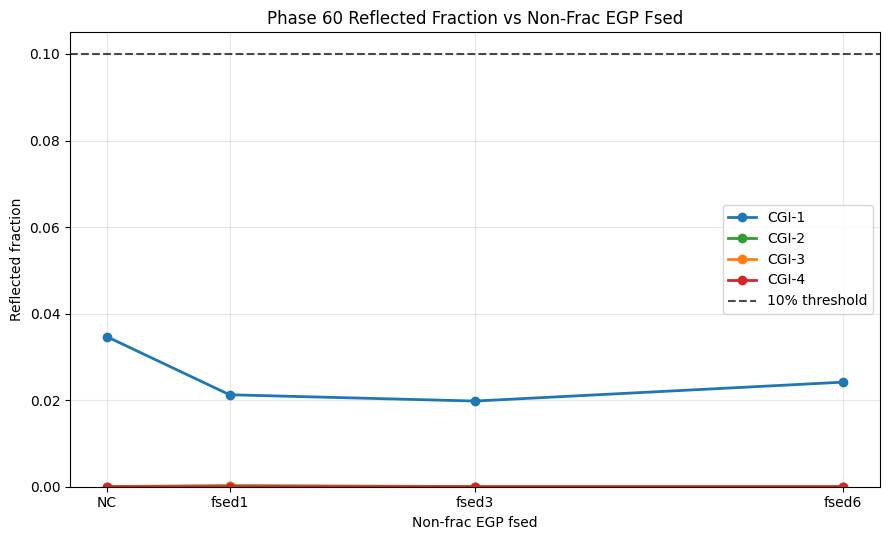

Saved fsed-sweep plot to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t1000_a5_g31_fsed_sweep/roadrunner_egp_phase60_T1000_a5_g31_fsed_sweep.png


In [5]:
fsed_table = fsed_sweep_pivot(sweep_df)
display(fsed_table)

ax = plot_phase60_fsed_sweep(sweep_df)
plt.tight_layout()
ax.figure.savefig(OUTPUT_PNG, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved fsed-sweep plot to: {OUTPUT_PNG}")


## Validation


In [6]:
expected_rows = len(RUN_FSED_VALUES) * len(CGI_BANDS)

assert len(sweep_df) == expected_rows, f"Expected {expected_rows} rows, got {len(sweep_df)}"
assert list(sweep_df.sort_values("fsed_numeric")["fsed"].drop_duplicates()) == RUN_FSED_VALUES
assert sweep_df["gravity_code"].nunique() == 1
assert str(sweep_df["gravity_code"].iloc[0]) == GRAVITY_CODE
assert sweep_df["phase_deg"].nunique() == 1
assert float(sweep_df["phase_deg"].iloc[0]) == PHASE_DEG
assert sweep_df["T_eff"].nunique() == 1
assert float(sweep_df["T_eff"].iloc[0]) == float(TEMPERATURE_K)
assert sweep_df["a_AU"].nunique() == 1
assert float(sweep_df["a_AU"].iloc[0]) == float(SEMI_MAJOR_AU)
assert sweep_df["f_reflect"].notna().all()
assert not sweep_df["pt_file"].str.contains("_frac", regex=False).any()
assert not sweep_df["cld_file"].fillna("").str.contains("_frac", regex=False).any()
assert not sweep_df["egp_irflux_file"].str.contains("_frac", regex=False).any()
assert OUTPUT_CSV.exists()
assert OUTPUT_PNG.exists()

expected_irflux = {
    (
        f"SLGRID_T{TEMPERATURE_K}_g{GRAVITY_CODE}_m{METALLICITY}_CO{CO_RATIO}_NC_IRflux.txt"
        if fsed == "NC"
        else f"SLGRID_T{TEMPERATURE_K}_g{GRAVITY_CODE}_m{METALLICITY}_CO{CO_RATIO}_fsed{fsed}_IRflux.txt"
    )
    for fsed in RUN_FSED_VALUES
}
assert set(sweep_df["egp_irflux_file"]) == expected_irflux

print("Validation passed for available fixed phase-60 non-frac Route C fsed cases.")
print(f"CSV: {OUTPUT_CSV}")
print(f"PNG: {OUTPUT_PNG}")
if not missing_inventory.empty:
    print(f"Skipped cases still missing exact inputs: {missing_inventory['fsed'].tolist()}")


Validation passed for available fixed phase-60 non-frac Route C fsed cases.
CSV: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t1000_a5_g31_fsed_sweep/roadrunner_egp_phase60_T1000_a5_g31_fsed_sweep.csv
PNG: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/phase60_t1000_a5_g31_fsed_sweep/roadrunner_egp_phase60_T1000_a5_g31_fsed_sweep.png
Skipped cases still missing exact inputs: ['0.3', '8']
